# 데이터프레임 합치기

*   merge: 두 개 이상의 데이터프레임을 공통된 컬럼(들)을 기준으로 합치는 것.SQL의 join과 비슷.
*   concat: 두 개 이상의 데이터프레임을 축(axis)을 따라서 합치는 것.


# 모듈 임포트

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# merge

In [2]:
emp = pd.DataFrame(data={
    'empno': [101,102,201,202],
    'ename': ['Scott','King','Allen','오쌤'],
    'deptno': [10,20,10,40]
})
emp

,empno,ename,deptno
0,101,Scott,10
1,102,King,20
2,201,Allen,10
3,202,오쌤,40


In [3]:
dept = pd.DataFrame(data={
    'deptno': [10,20,30],
    'dname': ['HR','IT','Sales']
})
dept

,deptno,dname
0,10,HR
1,20,IT
2,30,Sales



*   `pd.merge(left, right, how, on, ...)` 함수
*   `pd.DataFrame,merge(right, how, on, ...)` 메서드
*   파라미터 `how`: merge 방식(inner, left, right, outer). 기본값은 inner.
*   파라미터 `on`: join 기준이 되는 컬럼(들의 리스트). join 컬럼 이름이 같은 경우에는 생략 가능.


inner join

In [4]:
pd.merge(left=emp, right=dept, how='inner') # 함수(function)

,empno,ename,deptno,dname
0,101,Scott,10,HR
1,102,King,20,IT
2,201,Allen,10,HR


In [5]:
emp.merge(dept) # 메서드(method)

,empno,ename,deptno,dname
0,101,Scott,10,HR
1,102,King,20,IT
2,201,Allen,10,HR


## left outer join

In [6]:
pd.merge(left=emp, right=dept, how='left')

,empno,ename,deptno,dname
0,101,Scott,10,HR
1,102,King,20,IT
2,201,Allen,10,HR
3,202,오쌤,40,NaN


In [7]:
emp.merge(dept,how='left')

,empno,ename,deptno,dname
0,101,Scott,10,HR
1,102,King,20,IT
2,201,Allen,10,HR
3,202,오쌤,40,NaN


## right outer join

In [8]:
pd.merge(left=emp,right=dept,how='right')

,empno,ename,deptno,dname
0,101.0,Scott,10,HR
1,201.0,Allen,10,HR
2,102.0,King,20,IT
3,NaN,NaN,30,Sales


In [9]:
emp.merge(dept,how='right')

,empno,ename,deptno,dname
0,101.0,Scott,10,HR
1,201.0,Allen,10,HR
2,102.0,King,20,IT
3,NaN,NaN,30,Sales


## full outer join

In [10]:
pd.merge(left=emp,right=dept,how='outer')

,empno,ename,deptno,dname
0,101.0,Scott,10,HR
1,201.0,Allen,10,HR
2,102.0,King,20,IT
3,NaN,NaN,30,Sales
4,202.0,오쌤,40,NaN


In [11]:
emp.merge(dept,how='outer')

,empno,ename,deptno,dname
0,101.0,Scott,10,HR
1,201.0,Allen,10,HR
2,102.0,King,20,IT
3,NaN,NaN,30,Sales
4,202.0,오쌤,40,NaN


join 조건 컬럼 이름이 다른 경우

In [12]:
dept2= pd.DataFrame(data={
    'dno':[10,20,30],
    'dname':['인사','아이티','영업']
})
dept2

,dno,dname
0,10,인사
1,20,아이티
2,30,영업


In [13]:
emp.merge(right=dept2, how='inner',left_on='deptno',right_on='dno')

,empno,ename,deptno,dno,dname
0,101,Scott,10,10,인사
1,102,King,20,20,아이티
2,201,Allen,10,10,인사


In [14]:
pd.merge(left=emp,right=dept2, how='inner',left_on='deptno',right_on='dno')

,empno,ename,deptno,dno,dname
0,101,Scott,10,10,인사
1,102,King,20,20,아이티
2,201,Allen,10,10,인사


In [15]:
# left outer join
emp.merge(right=dept2, how='left',left_on='deptno',right_on='dno')

,empno,ename,deptno,dno,dname
0,101,Scott,10,10.0,인사
1,102,King,20,20.0,아이티
2,201,Allen,10,10.0,인사
3,202,오쌤,40,NaN,NaN


In [16]:
# right outer join
emp.merge(right=dept2,how='right',left_on='deptno',right_on='dno')

,empno,ename,deptno,dno,dname
0,101.0,Scott,10.0,10,인사
1,201.0,Allen,10.0,10,인사
2,102.0,King,20.0,20,아이티
3,NaN,NaN,NaN,30,영업


In [17]:
# full outer join 3개이상부터는 merge 또해야한다
emp.merge(right=dept2, how='outer',left_on='deptno',right_on='dno')

,empno,ename,deptno,dno,dname
0,101.0,Scott,10.0,10.0,인사
1,201.0,Allen,10.0,10.0,인사
2,102.0,King,20.0,20.0,아이티
3,NaN,NaN,NaN,30.0,영업
4,202.0,오쌤,40.0,NaN,NaN


In [18]:
emp.merge(dept,how='cross')

,empno,ename,deptno_x,deptno_y,dname
0,101,Scott,10,10,HR
1,101,Scott,10,20,IT
2,101,Scott,10,30,Sales
3,102,King,20,10,HR
4,102,King,20,20,IT
5,102,King,20,30,Sales
6,201,Allen,10,10,HR
7,201,Allen,10,20,IT
8,201,Allen,10,30,Sales
9,202,오쌤,40,10,HR


## 인덱스(row label)로 merge

In [19]:
np.random.seed(1)

In [20]:
df1 = pd.DataFrame(data={
    'value1': np.random.randint(10,size=6),
    'value2': np.random.randint(100, size=6)
},index=['a','b','c']*2)
df1

,value1,value2
a,5,1
b,8,76
c,9,71
a,5,6
b,0,25
c,0,50


In [21]:
df2 = pd.DataFrame(data={
    'data1': np.random.rand(3),
    'data2': np.random.rand(3)
},index=['a','b','c'])
df2

,data1,data2
a,0.846311,0.443453
b,0.313274,0.229577
c,0.524548,0.534414


In [22]:
# left_index, right_index의 기본값은 False이다 >> True로 바꾸면, 조인할 때 인덱스를 사용함.
pd.merge(left=df1,right=df2,how='inner',left_index=True,right_index=True)

,value1,value2,data1,data2
a,5,1,0.846311,0.443453
b,8,76,0.313274,0.229577
c,9,71,0.524548,0.534414
a,5,6,0.846311,0.443453
b,0,25,0.313274,0.229577
c,0,50,0.524548,0.534414


In [23]:
df3 = pd.DataFrame(data={
    'value1': np.random.randint(10,size=6),
    'value2': np.random.randint(100, size=6),
    'value3': ['a','b','c']*2
})
df3

,value1,value2,value3
0,4,94,a
1,7,96,b
2,7,86,c
3,9,13,a
4,1,9,b
5,7,7,c


In [24]:
df4= pd.DataFrame(data={
    'data1':[10,20,30]
},index=['a','b','c'])
df4

,data1
a,10
b,20
c,30


In [101]:
# df3 데이터프레임의 컬럼과 df4 데이터프레임의 인덱스를 사용해서 조인
pd.merge(left=df3,right=df4,left_on='value3',right_index=True) # left right는 같이사용해야한다

,value1,value2,value3,data1
0,4,94,a,10
1,7,96,b,20
2,7,86,c,30
3,9,13,a,10
4,1,9,b,20
5,7,7,c,30


# concat

## Series에서의 concat

In [26]:
s1 = pd.Series(data=['scott','allen','king'])
s1

,0
0,scott
1,allen
2,king


In [27]:
s2 = pd.Series(data=['홍길동','오쌤'])
s2

,0
0,홍길동
1,오쌤


In [28]:
pd.concat([s1,s2]) #이어붙혀라 # objs 파라미터: Series 또는 DataFrame을 원소로 갖는 Iterable(list,tuple,ndarray)

,0
0,scott
1,allen
2,king
0,홍길동
1,오쌤


In [29]:
pd.concat([s1,s2],ignore_index=True)

,0
0,scott
1,allen
2,king
3,홍길동
4,오쌤


In [30]:
s3 = pd.Series(data=['HR','IT'])
s3

,0
0,HR
1,IT


In [103]:
pd.concat([s2,s3],axis=1)  # 같은종류 = axis=0 =기본값

,0,1
0,홍길동,HR
1,오쌤,IT


## DataFrame에서의 concat

In [32]:
np.random.seed(42)

In [33]:
score1= pd.DataFrame(data={
    'id':np.arange(1,6),
    'korean': np.random.randint(101,size=5),
    'english': np.random.randint(101,size=5),
    'math': np.random.randint(101,size=5)
})
score1

,id,korean,english,math
0,1,51,20,87
1,2,92,82,99
2,3,14,86,23
3,4,71,74,2
4,5,60,74,21


In [34]:
score2= pd.DataFrame(data={
    'id':np.arange(6,11),
    'korean': np.random.randint(101,size=5),
    'english': np.random.randint(101,size=5),
    'math': np.random.randint(101,size=5)
})
score2

,id,korean,english,math
0,6,52,1,75
1,7,1,63,57
2,8,87,59,21
3,9,29,20,88
4,10,37,32,48


In [35]:
pd.concat([score1,score2],ignore_index=True) # axis=0 기본값

,id,korean,english,math
0,1,51,20,87
1,2,92,82,99
2,3,14,86,23
3,4,71,74,2
4,5,60,74,21
5,6,52,1,75
6,7,1,63,57
7,8,87,59,21
8,9,29,20,88
9,10,37,32,48


In [36]:
score3=pd.DataFrame(data={
    'id':np.arange(1,6),
    'science':np.random.randint(101,size=5),
    'history':np.random.randint(101,size=5),
    'art':np.random.randint(101,size=5)
})
score3

,id,science,history,art
0,1,90,79,61
1,2,58,14,50
2,3,41,61,54
3,4,91,61,63
4,5,59,46,2


In [37]:
pd.concat([score1,score3],axis=1) # 붙일수있는모양에서만

,id,korean,english,math,id,science,history,art
0,1,51,20,87,1,90,79,61
1,2,92,82,99,2,58,14,50
2,3,14,86,23,3,41,61,54
3,4,71,74,2,4,91,61,63
4,5,60,74,21,5,59,46,2


In [105]:
asd=pd.merge(left=score1,right=score3)
asd

,id,korean,english,math,science,history,art
0,1,51,20,87,90,79,61
1,2,92,82,99,58,14,50
2,3,14,86,23,41,61,54
3,4,71,74,2,91,61,63
4,5,60,74,21,59,46,2


# merge, concat 연습 1.

미세먼지 농도 데이터셋

*   'https://github.com/pandas-dev/pandas/tree/main/doc/data' 데이터 사용
*   air_quality_no2_long.csv, air_quality_pm25_long.csv, air_quality_stations.csv 파일을 읽고, 각각 데이터프레임을 생성.
*   air_quality_no2 데이터프레임과 air_quality_pm25 데이터프레임을 합치세요.(merge? concat?)
*   위에서 만들어진 데이터프레임과 air_quality_stations 데이터프레임을 합치세요.(merge? concat?)
*   분석?

In [39]:
no2_file='https://raw.githubusercontent.com/pandas-dev/pandas/refs/heads/main/doc/data/air_quality_no2_long.csv'
pm25_file='https://raw.githubusercontent.com/pandas-dev/pandas/refs/heads/main/doc/data/air_quality_pm25_long.csv'
aqs_file='https://raw.githubusercontent.com/pandas-dev/pandas/refs/heads/main/doc/data/air_quality_stations.csv'

In [40]:
# parapeter unique
no2=pd.read_csv(no2_file)
pm25=pd.read_csv(pm25_file)
aqs=pd.read_csv(aqs_file)

In [41]:
no2

,city,country,date.utc,location,parameter,value,unit
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³
...,...,...,...,...,...,...,...
2063,London,GB,2019-05-07 06:00:00+00:00,London Westminster,no2,26.0,µg/m³
2064,London,GB,2019-05-07 04:00:00+00:00,London Westminster,no2,16.0,µg/m³
2065,London,GB,2019-05-07 03:00:00+00:00,London Westminster,no2,19.0,µg/m³
2066,London,GB,2019-05-07 02:00:00+00:00,London Westminster,no2,19.0,µg/m³


In [42]:
no2.city.unique()

array(['Paris', 'Antwerpen', 'London'], dtype=object)

In [43]:
pm25

,city,country,date.utc,location,parameter,value,unit
0,Antwerpen,BE,2019-06-18 06:00:00+00:00,BETR801,pm25,18.0,µg/m³
1,Antwerpen,BE,2019-06-17 08:00:00+00:00,BETR801,pm25,6.5,µg/m³
2,Antwerpen,BE,2019-06-17 07:00:00+00:00,BETR801,pm25,18.5,µg/m³
3,Antwerpen,BE,2019-06-17 06:00:00+00:00,BETR801,pm25,16.0,µg/m³
4,Antwerpen,BE,2019-06-17 05:00:00+00:00,BETR801,pm25,7.5,µg/m³
...,...,...,...,...,...,...,...
1105,London,GB,2019-05-07 06:00:00+00:00,London Westminster,pm25,9.0,µg/m³
1106,London,GB,2019-05-07 04:00:00+00:00,London Westminster,pm25,8.0,µg/m³
1107,London,GB,2019-05-07 03:00:00+00:00,London Westminster,pm25,8.0,µg/m³
1108,London,GB,2019-05-07 02:00:00+00:00,London Westminster,pm25,8.0,µg/m³


In [44]:
aqs

,location,coordinates.latitude,coordinates.longitude
0,BELAL01,51.23619,4.38522
1,BELHB23,51.17030,4.34100
2,BELLD01,51.10998,5.00486
3,BELLD02,51.12038,5.02155
4,BELR833,51.32766,4.36226
...,...,...,...
61,Southend-on-Sea,51.54420,0.67841
62,Southwark A2 Old Kent Road,51.48050,-0.05955
63,Thurrock,51.47707,0.31797
64,Tower Hamlets Roadside,51.52253,-0.04216


## no2 데이터프레임과 pm25 데이터프레임 concat

In [45]:
nopm=pd.concat([no2,pm25],ignore_index=True)
nopm

,city,country,date.utc,location,parameter,value,unit
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³
...,...,...,...,...,...,...,...
3173,London,GB,2019-05-07 06:00:00+00:00,London Westminster,pm25,9.0,µg/m³
3174,London,GB,2019-05-07 04:00:00+00:00,London Westminster,pm25,8.0,µg/m³
3175,London,GB,2019-05-07 03:00:00+00:00,London Westminster,pm25,8.0,µg/m³
3176,London,GB,2019-05-07 02:00:00+00:00,London Westminster,pm25,8.0,µg/m³


In [46]:
nopm.tail()

,city,country,date.utc,location,parameter,value,unit
3173,London,GB,2019-05-07 06:00:00+00:00,London Westminster,pm25,9.0,µg/m³
3174,London,GB,2019-05-07 04:00:00+00:00,London Westminster,pm25,8.0,µg/m³
3175,London,GB,2019-05-07 03:00:00+00:00,London Westminster,pm25,8.0,µg/m³
3176,London,GB,2019-05-07 02:00:00+00:00,London Westminster,pm25,8.0,µg/m³
3177,London,GB,2019-05-07 01:00:00+00:00,London Westminster,pm25,8.0,µg/m³


In [47]:
nopm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3178 entries, 0 to 3177
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   city       3178 non-null   object 
 1   country    3178 non-null   object 
 2   date.utc   3178 non-null   object 
 3   location   3178 non-null   object 
 4   parameter  3178 non-null   object 
 5   value      3178 non-null   float64
 6   unit       3178 non-null   object 
dtypes: float64(1), object(6)
memory usage: 173.9+ KB


## stations 데이터프레임

In [48]:
aqs

,location,coordinates.latitude,coordinates.longitude
0,BELAL01,51.23619,4.38522
1,BELHB23,51.17030,4.34100
2,BELLD01,51.10998,5.00486
3,BELLD02,51.12038,5.02155
4,BELR833,51.32766,4.36226
...,...,...,...
61,Southend-on-Sea,51.54420,0.67841
62,Southwark A2 Old Kent Road,51.48050,-0.05955
63,Thurrock,51.47707,0.31797
64,Tower Hamlets Roadside,51.52253,-0.04216


In [49]:
aqs[aqs.location=='FR04014']

,location,coordinates.latitude,coordinates.longitude
26,FR04014,48.83724,2.3939
27,FR04014,48.83722,2.3939


In [50]:
aqs.location.unique()

array(['BELAL01', 'BELHB23', 'BELLD01', 'BELLD02', 'BELR833', 'BELSA04',
       'BELWZ02', 'BETM802', 'BETN016', 'BETR801', 'BETR802', 'BETR803',
       'BETR805', 'BETR811', 'BETR815', 'BETR817', 'BETR820', 'BETR822',
       'BETR831', 'BETR834', 'BETR891', 'BETR893', 'BETR894', 'BETR897',
       'FR04004', 'FR04012', 'FR04014', 'FR04031', 'FR04037', 'FR04060',
       'FR04071', 'FR04118', 'FR04131', 'FR04135', 'FR04141', 'FR04143',
       'FR04179', 'FR04329', 'Camden Kerbside', 'Ealing Horn Lane',
       'Haringey Roadside', 'London Bexley', 'London Bloomsbury',
       'London Eltham', 'London Haringey Priory Park South',
       'London Harlington', 'London Harrow Stanmore', 'London Hillingdon',
       'London Marylebone Road', 'London N. Kensington',
       'London Teddington', 'London Teddington Bushy Park',
       'London Westminster', 'Southend-on-Sea',
       'Southwark A2 Old Kent Road', 'Thurrock', 'Tower Hamlets Roadside',
       'Groton Fort Griswold'], dtype=object)

In [51]:
## aqs 데이터프레임에서 중복데이터 제거

In [52]:
aqs.location.value_counts() # 중복데이터 찾기

,count
location,
FR04031,2
FR04014,2
FR04141,2
FR04143,2
FR04329,2
FR04135,2
FR04071,2
FR04118,2
BELAL01,1


In [53]:
# aqs 데이터프레임의 location 컬럼 값이 중복되는 행들을 제거
aqs.drop_duplicates(subset='location',inplace=True)#첫번째값을두고 나머지삭제
#subset 중복값들을 찾을 컬럼 이름(들의 리스트)
#inplace-True 원본 데이터프레임을 변경//
# False(기본값) 원본데이터프레임은 수정하지 않고,  중복된 값들이 제거된 새로운 데이터프레임을 리턴

In [54]:
aqs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58 entries, 0 to 65
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   location               58 non-null     object 
 1   coordinates.latitude   58 non-null     float64
 2   coordinates.longitude  58 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.8+ KB


## nopm과 중복된 값이 제거된 aqs를 merge(inner join)

In [55]:
df=pd.merge(left=nopm,right=aqs)

In [56]:
# df.head(n=10)
df

,city,country,date.utc,location,parameter,value,unit,coordinates.latitude,coordinates.longitude
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³,48.83724,2.39390
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³,48.83724,2.39390
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³,48.83724,2.39390
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³,48.83724,2.39390
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³,48.83724,2.39390
...,...,...,...,...,...,...,...,...,...
3173,London,GB,2019-05-07 06:00:00+00:00,London Westminster,pm25,9.0,µg/m³,51.49467,-0.13193
3174,London,GB,2019-05-07 04:00:00+00:00,London Westminster,pm25,8.0,µg/m³,51.49467,-0.13193
3175,London,GB,2019-05-07 03:00:00+00:00,London Westminster,pm25,8.0,µg/m³,51.49467,-0.13193
3176,London,GB,2019-05-07 02:00:00+00:00,London Westminster,pm25,8.0,µg/m³,51.49467,-0.13193


In [57]:
nopm.location.value_counts()

,count
location,
London Westminster,1978
FR04014,1004
BETR801,196


In [58]:
# lon=aqs[aqs.location=='London Westminster']
# fr=aqs[aqs.location== 'FR04014']
# bet=aqs[aqs.location=='BETR801']
# aqss=['London Westminster','FR04014','BETR801']


## nopm과 aqs를 merge(inner join)

In [59]:
nopmaqs=pd.merge(left=nopm,right=aqs)
# nopmaqs1=pd.merge(left=nopmaqs2,right=fr)
# nopmaqs=pd.merge(left=nopmaqs1,right=bet)
nopmaqs

,city,country,date.utc,location,parameter,value,unit,coordinates.latitude,coordinates.longitude
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³,48.83724,2.39390
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³,48.83724,2.39390
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³,48.83724,2.39390
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³,48.83724,2.39390
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³,48.83724,2.39390
...,...,...,...,...,...,...,...,...,...
3173,London,GB,2019-05-07 06:00:00+00:00,London Westminster,pm25,9.0,µg/m³,51.49467,-0.13193
3174,London,GB,2019-05-07 04:00:00+00:00,London Westminster,pm25,8.0,µg/m³,51.49467,-0.13193
3175,London,GB,2019-05-07 03:00:00+00:00,London Westminster,pm25,8.0,µg/m³,51.49467,-0.13193
3176,London,GB,2019-05-07 02:00:00+00:00,London Westminster,pm25,8.0,µg/m³,51.49467,-0.13193


In [60]:
nopmaqs[nopmaqs.location=='FR04014']

,city,country,date.utc,location,parameter,value,unit,coordinates.latitude,coordinates.longitude
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³,48.83724,2.3939
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³,48.83724,2.3939
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³,48.83724,2.3939
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³,48.83724,2.3939
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³,48.83724,2.3939
...,...,...,...,...,...,...,...,...,...
999,Paris,FR,2019-05-07 05:00:00+00:00,FR04014,no2,72.4,µg/m³,48.83724,2.3939
1000,Paris,FR,2019-05-07 04:00:00+00:00,FR04014,no2,61.9,µg/m³,48.83724,2.3939
1001,Paris,FR,2019-05-07 03:00:00+00:00,FR04014,no2,50.4,µg/m³,48.83724,2.3939
1002,Paris,FR,2019-05-07 02:00:00+00:00,FR04014,no2,27.7,µg/m³,48.83724,2.3939


In [61]:
nopmaqs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3178 entries, 0 to 3177
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   city                   3178 non-null   object 
 1   country                3178 non-null   object 
 2   date.utc               3178 non-null   object 
 3   location               3178 non-null   object 
 4   parameter              3178 non-null   object 
 5   value                  3178 non-null   float64
 6   unit                   3178 non-null   object 
 7   coordinates.latitude   3178 non-null   float64
 8   coordinates.longitude  3178 non-null   float64
dtypes: float64(3), object(6)
memory usage: 223.6+ KB


In [62]:
nopmaqs.describe()

,value,coordinates.latitude,coordinates.longitude
count,3178.000000,3178.000000,3178.000000
mean,20.627911,50.637552,0.947500
std,13.894456,1.225500,1.461356
min,0.000000,48.837240,-0.131930
25%,9.000000,48.837240,-0.131930
50%,18.000000,51.494670,-0.131930
75%,28.900000,51.494670,2.393900
max,97.000000,51.494670,4.431820


In [63]:
nopmaqs.parameter.unique()

array(['no2', 'pm25'], dtype=object)

In [64]:
nopmaqs.country.unique()

array(['FR', 'BE', 'GB'], dtype=object)

In [65]:
nopmaqs.location.unique()

array(['FR04014', 'BETR801', 'London Westminster'], dtype=object)

In [66]:
# sns.barplot(date=nopmaqs,y='value',x='location')
# plt.show()

## 문자열 타입을 시간 타입을 변환

In [67]:
df['date.utc']=pd.to_datetime(df['date.utc'],utc=True)


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3178 entries, 0 to 3177
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   city                   3178 non-null   object             
 1   country                3178 non-null   object             
 2   date.utc               3178 non-null   datetime64[ns, UTC]
 3   location               3178 non-null   object             
 4   parameter              3178 non-null   object             
 5   value                  3178 non-null   float64            
 6   unit                   3178 non-null   object             
 7   coordinates.latitude   3178 non-null   float64            
 8   coordinates.longitude  3178 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(3), object(5)
memory usage: 223.6+ KB


In [69]:
df

,city,country,date.utc,location,parameter,value,unit,coordinates.latitude,coordinates.longitude
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³,48.83724,2.39390
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³,48.83724,2.39390
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³,48.83724,2.39390
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³,48.83724,2.39390
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³,48.83724,2.39390
...,...,...,...,...,...,...,...,...,...
3173,London,GB,2019-05-07 06:00:00+00:00,London Westminster,pm25,9.0,µg/m³,51.49467,-0.13193
3174,London,GB,2019-05-07 04:00:00+00:00,London Westminster,pm25,8.0,µg/m³,51.49467,-0.13193
3175,London,GB,2019-05-07 03:00:00+00:00,London Westminster,pm25,8.0,µg/m³,51.49467,-0.13193
3176,London,GB,2019-05-07 02:00:00+00:00,London Westminster,pm25,8.0,µg/m³,51.49467,-0.13193


## London의 NO2, PM25 시계열 그래프

In [70]:
london_df=df[df.city=='London']
london_df

,city,country,date.utc,location,parameter,value,unit,coordinates.latitude,coordinates.longitude
1099,London,GB,2019-06-17 11:00:00+00:00,London Westminster,no2,11.0,µg/m³,51.49467,-0.13193
1100,London,GB,2019-06-17 10:00:00+00:00,London Westminster,no2,11.0,µg/m³,51.49467,-0.13193
1101,London,GB,2019-06-17 09:00:00+00:00,London Westminster,no2,11.0,µg/m³,51.49467,-0.13193
1102,London,GB,2019-06-17 08:00:00+00:00,London Westminster,no2,13.0,µg/m³,51.49467,-0.13193
1103,London,GB,2019-06-17 07:00:00+00:00,London Westminster,no2,13.0,µg/m³,51.49467,-0.13193
...,...,...,...,...,...,...,...,...,...
3173,London,GB,2019-05-07 06:00:00+00:00,London Westminster,pm25,9.0,µg/m³,51.49467,-0.13193
3174,London,GB,2019-05-07 04:00:00+00:00,London Westminster,pm25,8.0,µg/m³,51.49467,-0.13193
3175,London,GB,2019-05-07 03:00:00+00:00,London Westminster,pm25,8.0,µg/m³,51.49467,-0.13193
3176,London,GB,2019-05-07 02:00:00+00:00,London Westminster,pm25,8.0,µg/m³,51.49467,-0.13193


In [71]:
df.city.unique()

array(['Paris', 'Antwerpen', 'London'], dtype=object)

In [72]:
bel=df[df.city=='Antwerpen']
bel

,city,country,date.utc,location,parameter,value,unit,coordinates.latitude,coordinates.longitude
1004,Antwerpen,BE,2019-06-17 08:00:00+00:00,BETR801,no2,41.0,µg/m³,51.20966,4.43182
1005,Antwerpen,BE,2019-06-17 07:00:00+00:00,BETR801,no2,45.0,µg/m³,51.20966,4.43182
1006,Antwerpen,BE,2019-06-17 06:00:00+00:00,BETR801,no2,43.5,µg/m³,51.20966,4.43182
1007,Antwerpen,BE,2019-06-17 05:00:00+00:00,BETR801,no2,42.5,µg/m³,51.20966,4.43182
1008,Antwerpen,BE,2019-06-17 04:00:00+00:00,BETR801,no2,39.5,µg/m³,51.20966,4.43182
...,...,...,...,...,...,...,...,...,...
2164,Antwerpen,BE,2019-05-09 01:00:00+00:00,BETR801,pm25,4.5,µg/m³,51.20966,4.43182
2165,Antwerpen,BE,2019-05-08 02:00:00+00:00,BETR801,pm25,14.0,µg/m³,51.20966,4.43182
2166,Antwerpen,BE,2019-05-08 01:00:00+00:00,BETR801,pm25,14.5,µg/m³,51.20966,4.43182
2167,Antwerpen,BE,2019-05-07 02:00:00+00:00,BETR801,pm25,14.0,µg/m³,51.20966,4.43182


In [73]:
fra=df[df.city=='Paris']


In [74]:
nono=df[df.parameter=='no2']
nono

,city,country,date.utc,location,parameter,value,unit,coordinates.latitude,coordinates.longitude
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³,48.83724,2.39390
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³,48.83724,2.39390
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³,48.83724,2.39390
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³,48.83724,2.39390
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³,48.83724,2.39390
...,...,...,...,...,...,...,...,...,...
2063,London,GB,2019-05-07 06:00:00+00:00,London Westminster,no2,26.0,µg/m³,51.49467,-0.13193
2064,London,GB,2019-05-07 04:00:00+00:00,London Westminster,no2,16.0,µg/m³,51.49467,-0.13193
2065,London,GB,2019-05-07 03:00:00+00:00,London Westminster,no2,19.0,µg/m³,51.49467,-0.13193
2066,London,GB,2019-05-07 02:00:00+00:00,London Westminster,no2,19.0,µg/m³,51.49467,-0.13193


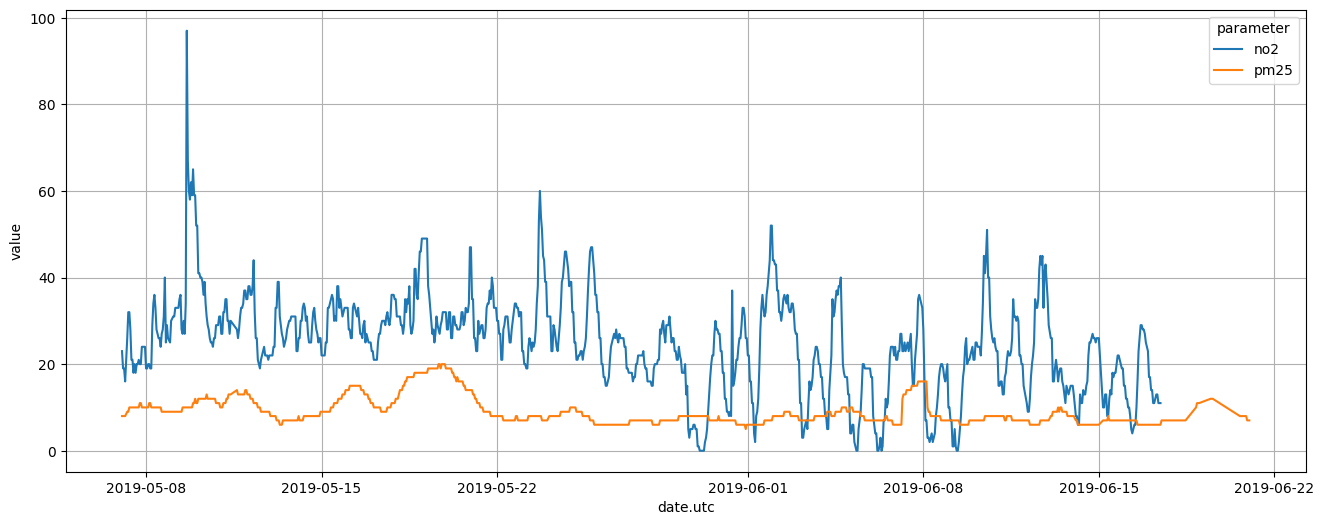

In [75]:
plt.figure(figsize=(16,6))# 같은도시 // 다른도시 no2 도시별
sns.lineplot(data=london_df, x='date.utc',y='value',hue='parameter')
plt.grid()
plt.show()

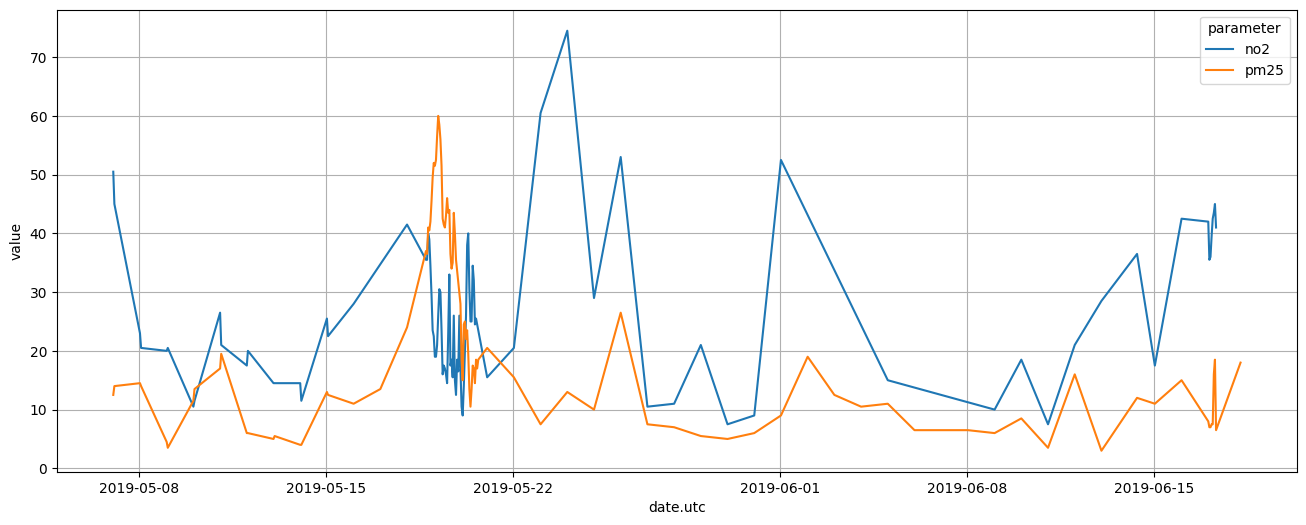

In [76]:
plt.figure(figsize=(16,6))
sns.lineplot(data=bel,x='date.utc',y='value',hue='parameter')
plt.grid()
plt.show()

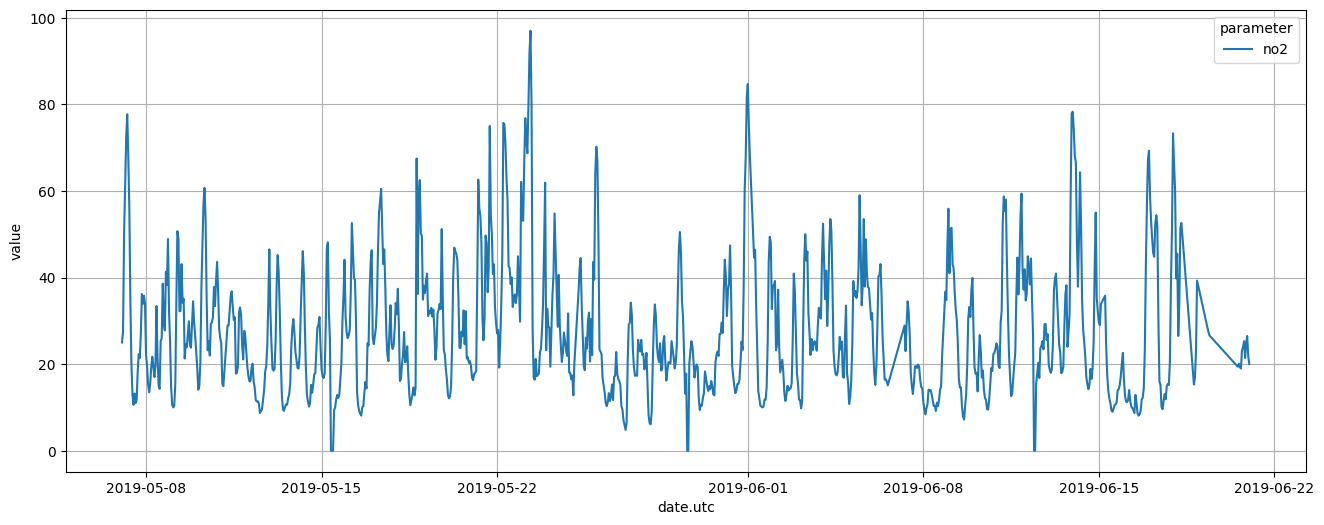

In [77]:
plt.figure(figsize=(16,6))
sns.lineplot(data=fra,x='date.utc',y='value',hue='parameter')
plt.grid()
plt.show()

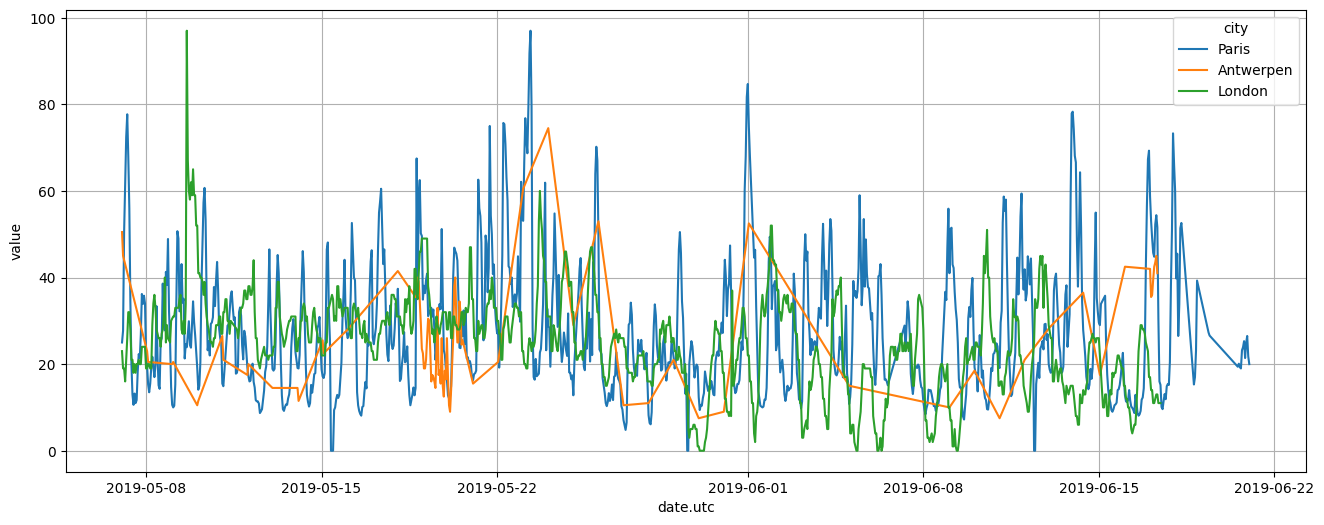

In [78]:
plt.figure(figsize=(16,6))# 같은도시 // 다른도시 no2 도시별
sns.lineplot(data=nono, x='date.utc',y='value',hue='city',errorbar=None)
plt.grid()
plt.show()

# merge, concat

미국 신생아 이름 데이터셋

*   https://github.com/wesm/pydata-book/tree/3rd-edition/datasets/babynames 데이터 파일들을 사용
*   1880년부터 2010년까지 미국 신생아들의 이름, 성별, 출생자수가 정리된 파일들
*   파일을 하나씩 읽어서 데이터프레임들 생성.
*   각각의 데이터프레임에 year 컬럼을 추가.
*   생성된 131개의 데이터프레임들을 하나로 합치세요.(merge? concat?)
*   연도별 신생아 수를 찾고 그래프를 그리세요.
*   연도별 성별 신생아 수를 찾고 그래프를 그리세요.

In [79]:
babyyob1='https://raw.githubusercontent.com/wesm/pydata-book/refs/heads/3rd-edition/datasets/babynames/yob1880.txt'

In [80]:
babyyob=pd.read_csv(babyyob1,names=["name", "sex", "count"])
babyyob

,name,sex,count
0,Mary,F,7065
1,Anna,F,2604
2,Emma,F,2003
3,Elizabeth,F,1939
4,Minnie,F,1746
...,...,...,...
1995,Woodie,M,5
1996,Worthy,M,5
1997,Wright,M,5
1998,York,M,5


In [81]:
dfs=[]
for x in range(1880,2011):
  babyyob1=f'https://raw.githubusercontent.com/wesm/pydata-book/refs/heads/3rd-edition/datasets/babynames/yob{x}.txt'
  df = pd.read_csv(
        babyyob1,
        names=["name", "sex", "count"]
    )
  # dfs.append(pd.read_csv(babyyob1))

  df["year"] = x
  dfs.append(df)

dfs = pd.concat(dfs, ignore_index=True)
dfs

,name,sex,count,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880
...,...,...,...,...
1690779,Zymaire,M,5,2010
1690780,Zyonne,M,5,2010
1690781,Zyquarius,M,5,2010
1690782,Zyran,M,5,2010


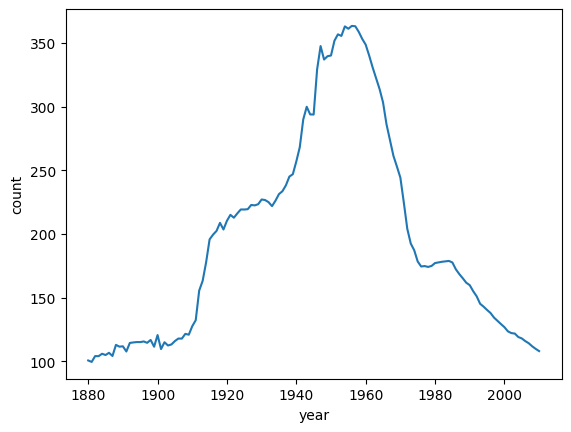

In [82]:
sns.lineplot(data=dfs, x='year',y='count',errorbar=None)
plt.show()

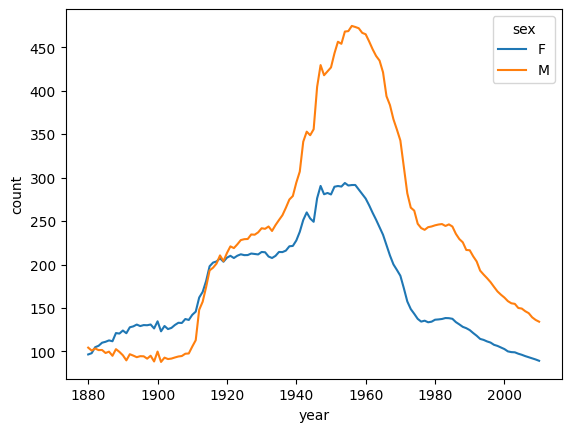

In [83]:
sns.lineplot(data=dfs, x='year',y='count',hue='sex',errorbar=None)
plt.show()

In [84]:
col_names=['name','gender','births']
yobs = [] # 각 연도의 데이터프레임을 저장할 빈 리스트
for year in range(1880,2011):
  # txt 파일의 github 경로
  file_path=f'https://raw.githubusercontent.com/wesm/pydata-book/refs/heads/3rd-edition/datasets/babynames/yob{year}.txt'
  # print(file_path)
  # 파일을 읽고 데이터 프레임을 생성
  yob_year=pd.read_csv(file_path,names=col_names)

  # 데이터프레임에 year 파생변수 추가
  yob_year['year']=year

  # 데이터프레임을 리스트에 추가
  yobs.append(yob_year)

In [85]:
len(yobs) # 131개의 DataFrame을 저장.

131

In [86]:
yobs[0] #> 리스트의 첫번째 아이템은 - 1880년 데이터프레임

,name,gender,births,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880
...,...,...,...,...
1995,Woodie,M,5,1880
1996,Worthy,M,5,1880
1997,Wright,M,5,1880
1998,York,M,5,1880


In [87]:
yobs[-1] #> 리스트의 마지막 아이템 - 2010년 데이터프레임

,name,gender,births,year
0,Isabella,F,22731,2010
1,Sophia,F,20477,2010
2,Emma,F,17179,2010
3,Olivia,F,16860,2010
4,Ava,F,15300,2010
...,...,...,...,...
33833,Zymaire,M,5,2010
33834,Zyonne,M,5,2010
33835,Zyquarius,M,5,2010
33836,Zyran,M,5,2010


In [88]:
# 131개의 데이터프레임을 axis=0 방향으로 concat(이어붙이기)
yob_df = pd.concat(yobs, ignore_index=True)

In [89]:
yob_df

,name,gender,births,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880
...,...,...,...,...
1690779,Zymaire,M,5,2010
1690780,Zyonne,M,5,2010
1690781,Zyquarius,M,5,2010
1690782,Zyran,M,5,2010


In [90]:
yob_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1690784 entries, 0 to 1690783
Data columns (total 4 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   name    1690784 non-null  object
 1   gender  1690784 non-null  object
 2   births  1690784 non-null  int64 
 3   year    1690784 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 51.6+ MB


## 연도별 신생아 수

In [91]:
yob_by_year = yob_df.groupby(by=['year']).births.sum()
yob_by_year

,births
year,
1880,201486
1881,192703
1882,221538
1883,216954
1884,243466
...,...
2006,3946702
2007,3986130
2008,3915955


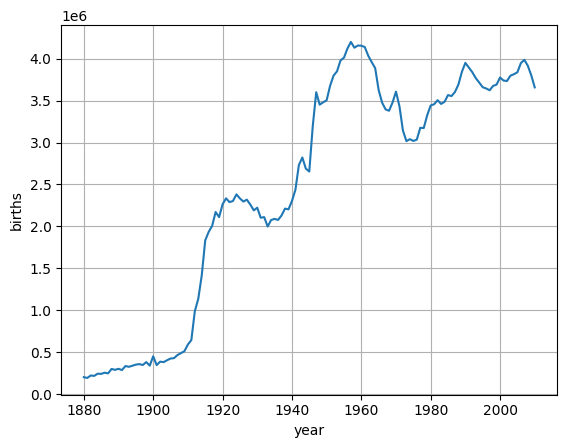

In [92]:
sns.lineplot(data=yob_by_year)
plt.grid()
plt.show()

## 연도별 성별 신생아 수

In [93]:
yob_by_year_gender=yob_df.groupby(by=['year','gender']).births.sum() # estimator='sum'도 가능하다

In [94]:
yob_by_year_gender #axis=0

year  gender
1880  F           90993
      M          110493
1881  F           91955
      M          100748
1882  F          107851
                 ...   
2008  M         2032310
2009  F         1827643
      M         1973359
2010  F         1759010
      M         1898382
Name: births, Length: 262, dtype: int64

In [95]:
type(yob_by_year_gender)

pandas.core.series.Series

In [96]:
type(yob_by_year_gender1)

NameError: name 'yob_by_year_gender1' is not defined

In [ ]:
yob_by_year_gender1=yob_by_year_gender.reset_index() # 인덱스를 컬럼으로 변경시킴 저장은아님 // inplace=True 원본데이터저장 데이터프레임은가능 시리즈는 불가능
#                                시리즈를 데이터프레임으로 만들어서 hue를 이용하고 싶을때 사용하는용도라고 일단 생각

In [ ]:
# yob_by_year_gender(1).reset_index(inplace=True) #데이터프레임으로 만들어서 성공된듯

In [ ]:
yob_by_year_gender1 # axis 0, 1

In [ ]:
# yob_by_year_gender

In [ ]:
sns.lineplot(data=yob_by_year_gender, x='year',y='births',hue='gender')
plt.show()

In [ ]:
# 1차원 리스트
# 2차원 리스트
# S vs DF